In [1]:
import sqlite3
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans

# Récupérer Data

In [2]:
con = sqlite3.connect("olist.db")
sql = pd.read_sql_query("Select * from rfm_table", con)
data = pd.DataFrame(sql)

data.shape

(110840, 5)

In [3]:
data.head()

,order_id,customer_unique_id,order_purchase_timestamp,review_score,price
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2.458029e+06,4.0,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2.458324e+06,4.0,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2.458339e+06,5.0,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2.458076e+06,5.0,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2.458163e+06,5.0,19.90


In [4]:
data.duplicated().sum()

np.int64(11577)

In [5]:
data = data.drop_duplicates()

In [6]:
agg = data.groupby("customer_unique_id").agg(
     frequency=pd.NamedAgg(column="order_id", aggfunc="count"),
     recency=pd.NamedAgg(column="order_purchase_timestamp", aggfunc="max"),
     monetary=pd.NamedAgg(column="price", aggfunc="sum"),
     contentment=pd.NamedAgg(column="review_score", aggfunc="mean")
)

agg.head()

,frequency,recency,monetary,contentment
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,2.458249e+06,129.90,5.0
0000b849f77a49e4a4ce2b2a4ca5be3f,1,2.458246e+06,18.90,4.0
0000f46a3911fa3c0805444483337064,1,2.457823e+06,69.00,3.0
0000f6ccb0745a6a4b88665a16c9f078,1,2.458039e+06,25.99,4.0
0004aac84e0df4da2b147fca70cf8255,1,2.458072e+06,180.00,5.0


# Nettoyer Data

In [7]:
agg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93358 entries, 0000366f3b9a7992bf8c76cfdf3221e2 to ffffd2657e2aad2907e67c3e9daecbeb
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   frequency    93358 non-null  int64  
 1   recency      93358 non-null  float64
 2   monetary     93358 non-null  float64
 3   contentment  92755 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 3.6+ MB


In [8]:
agg["recency"] = round(data["order_purchase_timestamp"].max() - agg["recency"])

In [9]:
agg.loc[agg["contentment"].isna(), "contentment"] = agg["contentment"].median()

In [10]:
agg["monetary"] = np.log(agg["monetary"])

In [ ]:
agg.head()

In [ ]:
raise AssertionError

In [ ]:
scaler = StandardScaler()
agg["monetary"] = scaler.fit_transform(agg[["monetary"]])
agg["recency"] = scaler.fit_transform(agg[["recency"]])
agg["contentment"] = scaler.fit_transform(agg[["contentment"]])

r_scaler = RobustScaler()
agg["frequency"] = r_scaler.fit_transform(agg[["frequency"]])

In [12]:
agg.describe()

,frequency,recency,monetary,contentment,recency_for_sampling
count,93358.000000,9.335800e+04,9.335800e+04,9.335800e+04,93358.000000
mean,0.063251,-8.828698e-17,7.455303e-16,-6.480531e-16,237.519527
std,0.302973,1.000005e+00,1.000005e+00,1.000005e+00,152.596929
min,0.000000,-1.556524e+00,-4.905482e+00,-2.471788e+00,0.000000
25%,0.000000,-8.094540e-01,-6.453508e-01,-1.243405e-01,114.000000
50%,0.000000,-1.213630e-01,-1.971952e-02,6.581422e-01,219.000000
75%,0.000000,7.108993e-01,6.419413e-01,6.581422e-01,346.000000
max,14.000000,3.115941e+00,4.834970e+00,6.581422e-01,713.000000


# Visualiser Data

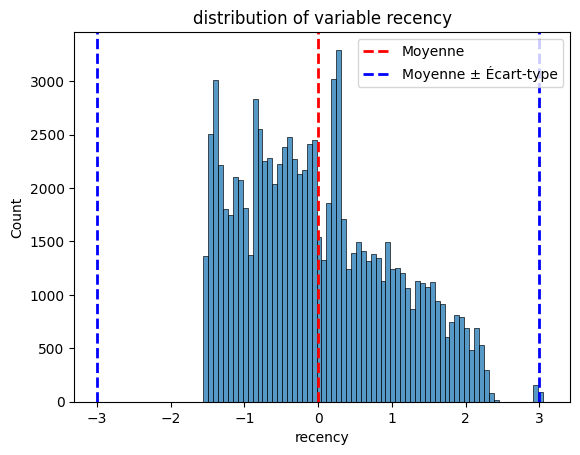

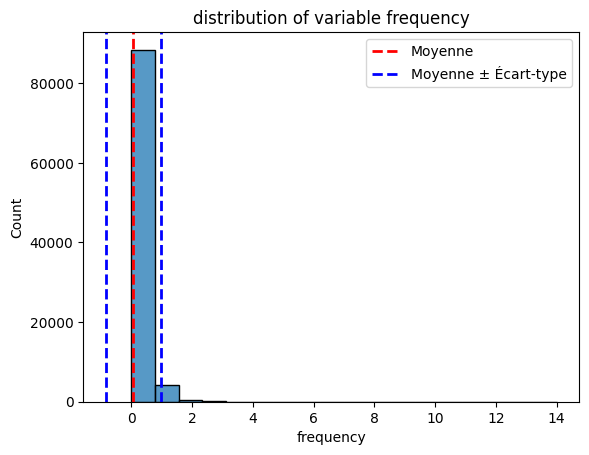

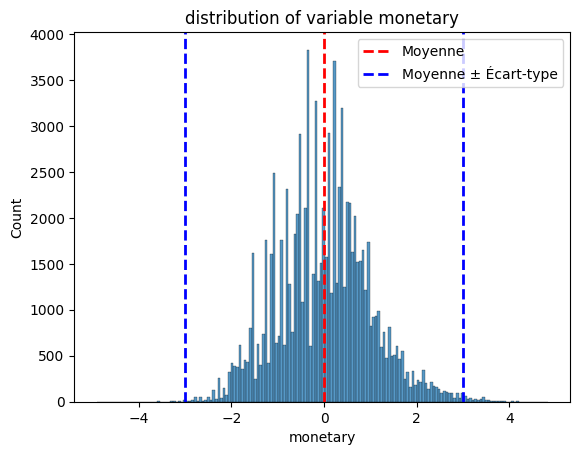

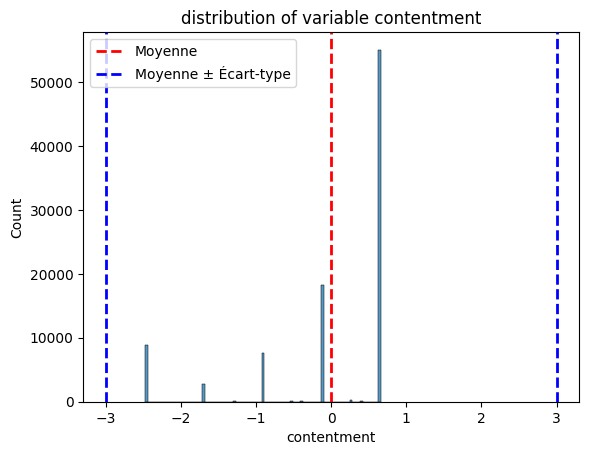

In [13]:
for col in ["recency", "frequency", "monetary", "contentment"]:
    values = agg[col]
        
    mean_val = values.mean()
    std_val = values.std()
    
    sns.histplot(values)
    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label='Moyenne')
    plt.axvline(mean_val - 3*std_val, color='blue', linestyle='dashed', linewidth=2, label='Moyenne ± Écart-type')
    plt.axvline(mean_val + 3*std_val, color='blue', linestyle='dashed', linewidth=2)

    plt.title(f"distribution of variable {col}") 
    plt.legend()
    plt.show()

<Axes: >

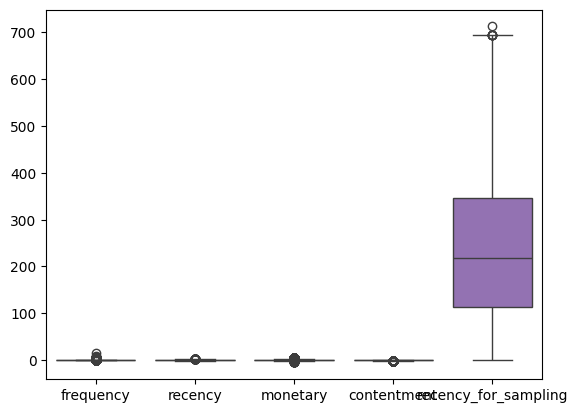

In [14]:
sns.boxplot(data=agg)

<Axes: >

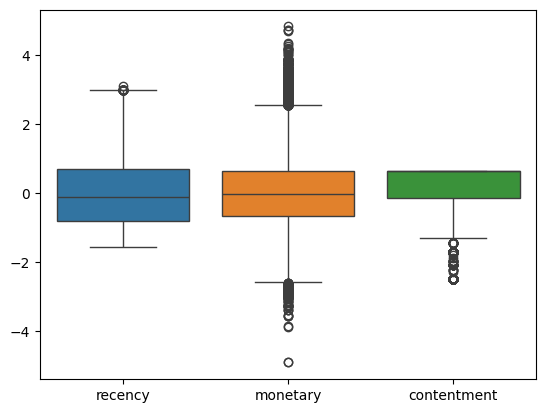

In [17]:
sns.boxplot(data=agg[["recency", "monetary", "contentment"]])

In [18]:
fig = px.scatter_3d(
    agg,
    x='recency',
    y='frequency',
    z='monetary',
    title='3D Scatter Plot',
    opacity=0.8
)

# Personnalisation
fig.update_traces(marker=dict(size=5))  # Taille des points
fig.update_layout(scene=dict(
    xaxis_title='Recency Score',
    yaxis_title='Frequency Score',
    zaxis_title='Monetary Score'
))

# Afficher l'interactivité
fig.show()

In [19]:
fig = px.scatter_3d(
    agg,
    x='recency',
    y='contentment',
    z='monetary',
    title='3D Scatter Plot',
    opacity=0.8
)

# Personnalisation
fig.update_traces(marker=dict(size=5))  # Taille des points
fig.update_layout(scene=dict(
    xaxis_title='Recency Score',
    yaxis_title='Contentment Score',
    zaxis_title='Monetary Score'
))

# Afficher l'interactivité
fig.show()

In [20]:
agg.to_csv("data_cleaned.csv")